In [24]:
from project.utilities.simulation import run_trials, run_task, TrialParams, run_experiments, DotsParams, get_CI
from project.utilities.statistics import bootstrap_ci, bootstrap_difference_ci
from project.utilities.io import load_results, save_plot, use_latex_fonts, figure_size

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import SeedSequence, default_rng
from dataclasses import asdict, replace
from scipy.stats import bootstrap
from statsmodels.stats.proportion import proportion_confint

from pathlib import Path
import pandas as pd

from project.networks.cbgt import ModelParams, ThalamusParams, BGParams, CBGT
from project.networks.cortex import CortexParams

# For displaying
from IPython.display import display, HTML

# Change font of plots
use_latex_fonts()

# Import Data

### Summary Statistics

Importing the data generated by `notebooks/learning/suite3.py`

In [25]:
summary_stats_m10 = load_results('suite3_m10_summary.csv', '../../data/learning') 
summary_stats_10 = load_results('suite3_10_summary.csv', '../../data/learning')
summary_stats_20 = load_results('suite3_20_summary.csv', '../../data/learning')


Loaded: ..\..\data\learning\suite3_m10_summary.csv
Loaded: ..\..\data\learning\suite3_10_summary.csv
Loaded: ..\..\data\learning\suite3_20_summary.csv


The model paramaters are carefully designed not to give rise to any premature decision. For completeness, this can quickly be verified.

In [26]:
print('Amount of premature decision with pathway bias = -0.10:', summary_stats_m10['Premature (%)'].sum())
print('Amount of premature decision with pathway bias = 0.10:', summary_stats_10['Premature (%)'].sum())
print('Amount of premature decision with pathway bias = 0.20:', summary_stats_20['Premature (%)'].sum())

Amount of premature decision with pathway bias = -0.10: 0.0
Amount of premature decision with pathway bias = 0.10: 0.0
Amount of premature decision with pathway bias = 0.20: 0.0


As expected, no premature decisions.

### Trial data

Importing trial data

In [27]:
# Index by trial_id
trial_data_m10 = load_results('suite3_m10_trials.csv', '../../data/learning', index_col = 'trial_id') 
trial_data_10 = load_results('suite3_10_trials.csv', '../../data/learning', index_col = 'trial_id')
trial_data_20 = load_results('suite3_20_trials.csv', '../../data/learning', index_col = 'trial_id')


Loaded: ..\..\data\learning\suite3_m10_trials.csv
Loaded: ..\..\data\learning\suite3_10_trials.csv
Loaded: ..\..\data\learning\suite3_20_trials.csv


# Plotting Data

Splitting data by noise level for each pathway bias

In [28]:
# ===== Split data by noise level =====
# Pathway bias = -0.10
df_0125_m10 = summary_stats_m10[summary_stats_m10['noise_std'] == 0.125]
df_025_m10 = summary_stats_m10[summary_stats_m10['noise_std'] == 0.25]
df_05_m10 = summary_stats_m10[summary_stats_m10['noise_std'] == 0.5]

# Pathway bias = 0.10
df_0125_10 = summary_stats_10[summary_stats_10['noise_std'] == 0.125]
df_025_10 = summary_stats_10[summary_stats_10['noise_std'] == 0.25]
df_05_10 = summary_stats_10[summary_stats_10['noise_std'] == 0.5]

# Pathway bias = 0.20
df_0125_20 = summary_stats_20[summary_stats_20['noise_std'] == 0.125]
df_025_20 = summary_stats_20[summary_stats_20['noise_std'] == 0.25]
df_05_20 = summary_stats_20[summary_stats_20['noise_std'] == 0.5]


# ==== Get mean and confidence intervals for each noise level ====
# --- Accuracy ---
acc_0125_m10, acc_err_0125_m10 = get_CI(df_0125_m10, metric='Accuracy (%)')
acc_025_m10, acc_err_025_m10 = get_CI(df_025_m10, metric='Accuracy (%)')
acc_05_m10, acc_err_05_m10 = get_CI(df_05_m10, metric='Accuracy (%)')

acc_0125_10, acc_err_0125_10 = get_CI(df_0125_10, metric='Accuracy (%)')
acc_025_10, acc_err_025_10 = get_CI(df_025_10, metric='Accuracy (%)')
acc_05_10, acc_err_05_10 = get_CI(df_05_10, metric='Accuracy (%)')

acc_0125_20, acc_err_0125_20 = get_CI(df_0125_20, metric='Accuracy (%)')
acc_025_20, acc_err_025_20 = get_CI(df_025_20, metric='Accuracy (%)')
acc_05_20, acc_err_05_20 = get_CI(df_05_20, metric='Accuracy (%)')

# --- Post-decision variability ---
pdv_0125_m10, pdv_err_0125_m10 = get_CI(df_0125_m10, metric='Mean PD Variability')
pdv_025_m10, pdv_err_025_m10 = get_CI(df_025_m10, metric='Mean PD Variability')
pdv_05_m10, pdv_err_05_m10 = get_CI(df_05_m10, metric='Mean PD Variability')

pdv_0125_10, pdv_err_0125_10 = get_CI(df_0125_10, metric='Mean PD Variability')
pdv_025_10, pdv_err_025_10 = get_CI(df_025_10, metric='Mean PD Variability')
pdv_05_10, pdv_err_05_10 = get_CI(df_05_10, metric='Mean PD Variability')

pdv_0125_20, pdv_err_0125_20 = get_CI(df_0125_20, metric='Mean PD Variability')
pdv_025_20, pdv_err_025_20 = get_CI(df_025_20, metric='Mean PD Variability')
pdv_05_20, pdv_err_05_20 = get_CI(df_05_20, metric='Mean PD Variability')

# --- Mistakes ---
mistakes_0125_m10, mistakes_err_0125_m10 = get_CI(df_0125_m10, metric='Wrong Decision (%)')
mistakes_025_m10, mistakes_err_025_m10 = get_CI(df_025_m10, metric='Wrong Decision (%)')
mistakes_05_m10, mistakes_err_05_m10 = get_CI(df_05_m10, metric='Wrong Decision (%)')

mistakes_0125_10, mistakes_err_0125_10 = get_CI(df_0125_10, metric='Wrong Decision (%)')
mistakes_025_10, mistakes_err_025_10 = get_CI(df_025_10, metric='Wrong Decision (%)')
mistakes_05_10, mistakes_err_05_10 = get_CI(df_05_10, metric='Wrong Decision (%)')

mistakes_0125_20, mistakes_err_0125_20 = get_CI(df_0125_20, metric='Wrong Decision (%)')
mistakes_025_20, mistakes_err_025_20 = get_CI(df_025_20, metric='Wrong Decision (%)')
mistakes_05_20, mistakes_err_05_20 = get_CI(df_05_20, metric='Wrong Decision (%)')


Plotting relevant summary statistics

### Accuracy, post-decision variability and mistakes vs coherence

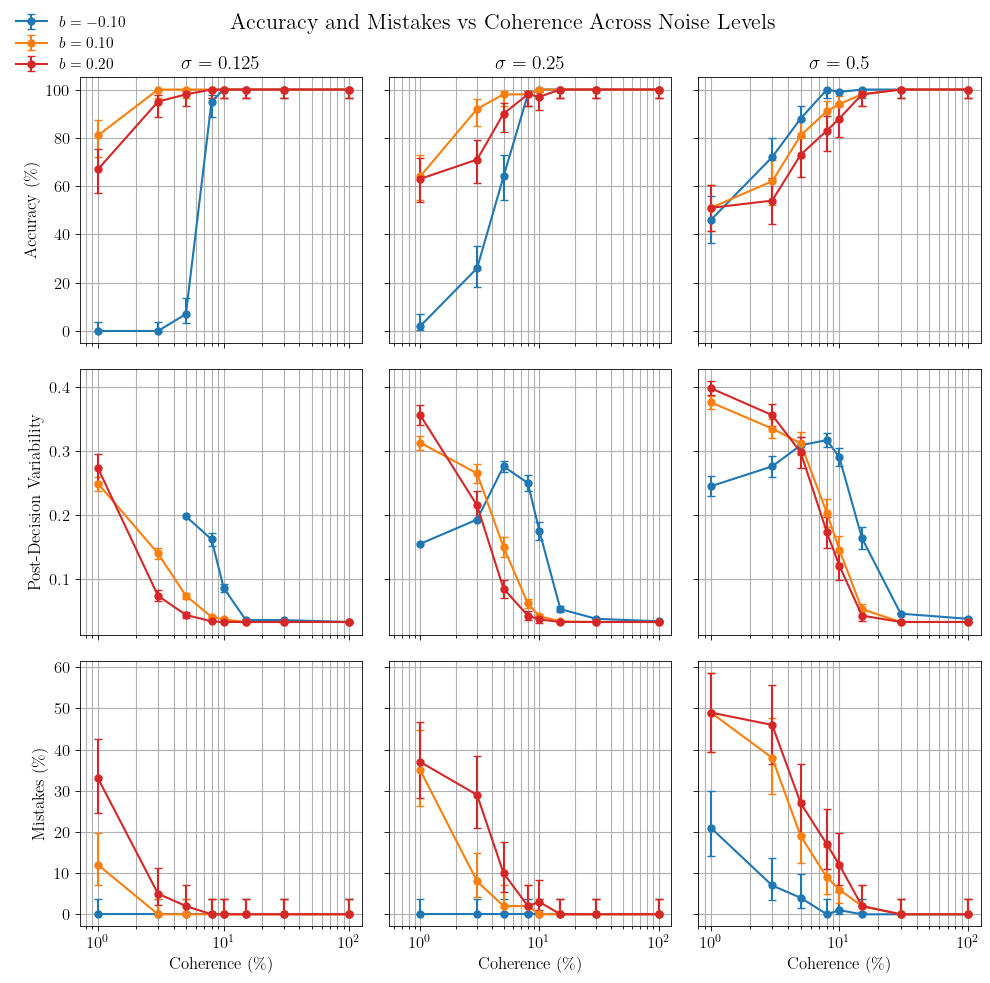

Saved: ..\..\figures\learning\suite3\Accuracy and Mistakes vs Coherence.pdf
Saved: ..\..\figures\learning\suite3\Accuracy and Mistakes vs Coherence.png


In [29]:
# ==== Plotting ====
coherences = summary_stats_m10['coherence'].unique() * 100
fig, ax = plt.subplots(3, 3, figsize=figure_size('triple'), subplot_kw={"xscale": "log"}, sharex='col', sharey='row')

# Accuracy
ax[0, 0].errorbar(x=coherences, y=acc_0125_m10, yerr=acc_err_0125_m10, fmt='o-', capsize=3, markersize=5, label=r'$b = -0.10$')
ax[0, 0].errorbar(x=coherences, y=acc_0125_10, yerr=acc_err_0125_10, fmt='o-', capsize=3, markersize=5, label=r'$b = 0.10$')
ax[0, 0].errorbar(x=coherences, y=acc_0125_20, yerr=acc_err_0125_20, fmt='o-', capsize=3, markersize=5, label=r'$b = 0.20$', color = 'tab:red')
ax[0, 0].set_title('$\sigma = 0.125$')
ax[0, 0].set_ylabel('Accuracy (\%)')
ax[0, 0].grid(which='both')

ax[0, 1].errorbar(x=coherences, y=acc_025_m10, yerr=acc_err_025_m10, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=acc_025_10, yerr=acc_err_025_10, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=acc_025_20, yerr=acc_err_025_20, fmt='o-', capsize=3, markersize=5, color = "tab:red")
ax[0, 1].set_title('$\sigma = 0.25$')
ax[0, 1].grid(which='both')

ax[0, 2].errorbar(x=coherences, y=acc_05_m10, yerr=acc_err_05_m10, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=acc_05_10, yerr=acc_err_05_10, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=acc_05_20, yerr=acc_err_05_20, fmt='o-', capsize=3, markersize=5, color = "tab:red")
ax[0, 2].set_title('$\sigma = 0.5$')
ax[0, 2].grid(which='both')

# Post-decision variability
ax[1, 0].errorbar(x=coherences, y=pdv_0125_m10, yerr=pdv_err_0125_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=pdv_0125_10, yerr=pdv_err_0125_10, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=pdv_0125_20, yerr=pdv_err_0125_20, fmt='o-', capsize=3, markersize=5, color = "tab:red")
ax[1, 0].set_ylabel('Post-Decision Variability')
ax[1, 0].grid(which='both')

ax[1, 1].errorbar(x=coherences, y=pdv_025_m10, yerr=pdv_err_025_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=pdv_025_10, yerr=pdv_err_025_10, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=pdv_025_20, yerr=pdv_err_025_20, fmt='o-', capsize=3, markersize=5, color = "tab:red")
ax[1, 1].grid(which='both')

ax[1, 2].errorbar(x=coherences, y=pdv_05_m10, yerr=pdv_err_05_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=pdv_05_10, yerr=pdv_err_05_10, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=pdv_05_20, yerr=pdv_err_05_20, fmt='o-', capsize=3, markersize=5, color = "tab:red")
ax[1, 2].grid(which='both')

# Mistakes
ax[2, 0].errorbar(x=coherences, y=mistakes_0125_m10, yerr=mistakes_err_0125_m10, fmt='o-', capsize=3, markersize=5)
ax[2, 0].errorbar(x=coherences, y=mistakes_0125_10, yerr=mistakes_err_0125_10, fmt='o-', capsize=3, markersize=5)
ax[2, 0].errorbar(x=coherences, y=mistakes_0125_20, yerr=mistakes_err_0125_20, fmt='o-', capsize=3, markersize=5, color = "tab:red")
ax[2, 0].set_xlabel('Coherence (\%)')
ax[2, 0].set_ylabel('Mistakes (\%)')
ax[2, 0].grid(which='both')

ax[2, 1].errorbar(x=coherences, y=mistakes_025_m10, yerr=mistakes_err_025_m10, fmt='o-', capsize=3, markersize=5)
ax[2, 1].errorbar(x=coherences, y=mistakes_025_10, yerr=mistakes_err_025_10, fmt='o-', capsize=3, markersize=5)
ax[2, 1].errorbar(x=coherences, y=mistakes_025_20, yerr=mistakes_err_025_20, fmt='o-', capsize=3, markersize=5, color = "tab:red")
ax[2, 1].set_xlabel('Coherence (\%)')
ax[2, 1].grid(which='both')

ax[2, 2].errorbar(x=coherences, y=mistakes_05_m10, yerr=mistakes_err_05_m10, fmt='o-', capsize=3, markersize=5)
ax[2, 2].errorbar(x=coherences, y=mistakes_05_10, yerr=mistakes_err_05_10, fmt='o-', capsize=3, markersize=5)
ax[2, 2].errorbar(x=coherences, y=mistakes_05_20, yerr=mistakes_err_05_20, fmt='o-', capsize=3, markersize=5, color = "tab:red")
ax[2, 2].set_xlabel('Coherence (\%)')
ax[2, 2].grid(which='both')

fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.95), frameon=False)
plt.suptitle('Accuracy and Mistakes vs Coherence Across Noise Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Accuracy and Mistakes vs Coherence', folder='../../figures/learning/suite3', formats=('pdf', 'png'))

A higher pathway bias appears to improve accuracy by quite a margin at low coherence levels. Two trials are run at low coherence for at low and high pathway bias at low noise level

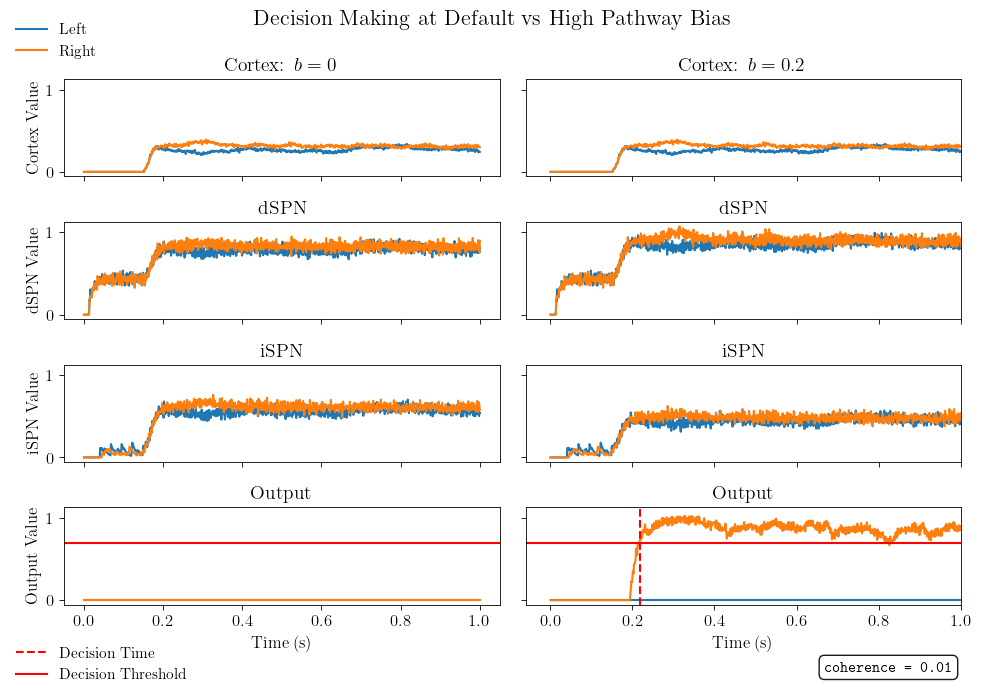

Saved: ..\..\figures\learning\suite3\Low vs High Pathway Bias.pdf
Saved: ..\..\figures\learning\suite3\Low vs High Pathway Bias.png


In [30]:
# ---- Parameters -----
task_seed = 1 
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
coherence = 0.01
noise_level = 0.125

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )

task_params = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = coherence,
    noise_std = noise_level
    )


# ---- Run decision-making task ----

# Low pathway bias
task_result_low = run_task(
    model_params = model_parameters,
    dots_params = task_params,
    trial_params = trial_params,
    return_probes = True,
    pathway_bias = -0.1
)
# High pathway bias
task_result_high = run_task(
    model_params = model_parameters,
    dots_params = task_params,
    trial_params = trial_params,
    return_probes = True,
    pathway_bias = 0.2
)

# ---- Get decision time for high pathway bias condition ----
decision_time_high = task_result_high.decision_info['RT (ms)']/1000 + t_warmup

# ---- Extract relevant probe data ----
probes_low= task_result_low.probes
probes_high= task_result_high.probes


# Time
time_low = probes_low['time']
time_high = probes_high['time']

# Cortex, dSPN, iSPN and output probes
cortex_probe_low = probes_low['cortex']
dSPN_probe_low = probes_low['dSPN']
iSPN_probe_low = probes_low['iSPN']
output_probe_low = probes_low['output']

cortex_probe_high = probes_high['cortex']
dSPN_probe_high = probes_high['dSPN']
iSPN_probe_high = probes_high['iSPN']
output_probe_high = probes_high['output']

# ---- Plot ----
fig, ax = plt.subplots(4, 2, figsize=figure_size('double'), sharex = 'col', sharey = True)

# Low noise
Left, = ax[0,0].plot(time_low, cortex_probe_low[:,0], label = 'Left')
Right, = ax[0,0].plot(time_low, cortex_probe_low[:,1], label = 'Right')
ax[0,0].set_title('Cortex: $b = 0$')


ax[1,0].plot(time_low, dSPN_probe_low[:,0])
ax[1,0].plot(time_low, dSPN_probe_low[:,1])
ax[1,0].set_title('dSPN')

ax[2,0].plot(time_low, iSPN_probe_low[:,0])
ax[2,0].plot(time_low, iSPN_probe_low[:,1])
ax[2,0].set_title('iSPN')

ax[3,0].plot(time_low, output_probe_low[:,0])
ax[3,0].plot(time_low, output_probe_low[:,1])
ax[3,0].axhline(decision_threshold, color='r', linestyle='-')
ax[3,0].set_title('Output')

# High pathway bias

ax[0,1].plot(time_high, cortex_probe_high[:,0])
ax[0,1].plot(time_high, cortex_probe_high[:,1])
ax[0,1].set_title('Cortex: $b = 0.2$')

ax[1,1].plot(time_high, dSPN_probe_high[:,0])
ax[1,1].plot(time_high, dSPN_probe_high[:,1])
ax[1,1].set_title('dSPN')

ax[2,1].plot(time_high, iSPN_probe_high[:,0])
ax[2,1].plot(time_high, iSPN_probe_high[:,1])
ax[2,1].set_title('iSPN')

ax[3,1].plot(time_high, output_probe_high[:,0])
ax[3,1].plot(time_high, output_probe_high[:,1])
ax[3,1].set_title('Output')
ax[3,1].set_xlim(right = 1)

# - Set axes labels -
# x-axis
ax[3,0].set_xlabel('Time (s)')
ax[3,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Cortex Value')
ax[1,0].set_ylabel('dSPN Value')
ax[2,0].set_ylabel('iSPN Value')
ax[3,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line = ax[3,1].axvline(decision_time_high, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[3,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}" 
)

fig.text(
    0.96, 0.05,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Decision Making at Default vs High Pathway Bias')
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

save_plot(fig, 'Low vs High Pathway Bias', folder='../../figures/learning/suite3', formats=('pdf', 'png'))

### Reaction Times

Plotting reaction times, only for default operating conditions

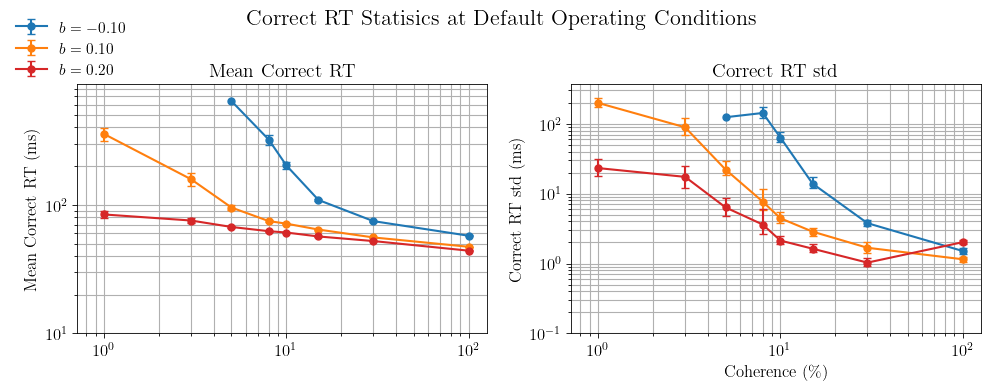

Saved: ..\..\figures\learning\suite3\Correct RT - Mean and Standard Deviation vs Coherence.pdf
Saved: ..\..\figures\learning\suite3\Correct RT - Mean and Standard Deviation vs Coherence.png


In [31]:
## ==== Get RT mean and std along with confidence intervals for noise_std = 0.125 ====
# --- RT Mean ---
RT_mean_0125_m10, RT_err_0125_m10 = get_CI(df_0125_m10, metric='Mean Correct RT (ms)')
RT_mean_0125_10, RT_err_0125_10 = get_CI(df_0125_10, metric='Mean Correct RT (ms)')
RT_mean_0125_20, RT_err_0125_20 = get_CI(df_0125_20, metric='Mean Correct RT (ms)')


# --- RT std ---
RT_std_0125_m10, RT_std_err_0125_m10 = get_CI(df_0125_m10, metric='Correct RT std (ms)')
RT_std_0125_10, RT_std_err_0125_10 = get_CI(df_0125_10, metric='Correct RT std (ms)')
RT_std_0125_20, RT_std_err_0125_20 = get_CI(df_0125_20, metric='Correct RT std (ms)')

# ==== Plotting ====
fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={"xscale": "log", "yscale": "log"})

# RT Mean
ax[0].errorbar(x=coherences, y=RT_mean_0125_m10, yerr=RT_err_0125_m10, fmt='o-', capsize=3, markersize=5, label=r'$b = -0.10$')
ax[0].errorbar(x=coherences, y=RT_mean_0125_10, yerr=RT_err_0125_10, fmt='o-', capsize=3, markersize=5, label=r'$b = 0.10$')
ax[0].errorbar(x=coherences, y=RT_mean_0125_20, yerr=RT_err_0125_20, fmt='o-', capsize=3, markersize=5, label=r'$b = 0.20$', color='tab:red')
ax[0].set_title('Mean Correct RT')
ax[0].set_ylabel('Mean Correct RT (ms)')
ax[0].grid(which='both')
ax[0].set_ylim(bottom=10)

# RT std
ax[1].errorbar(x=coherences, y=RT_std_0125_m10, yerr=RT_std_err_0125_m10, fmt='o-', capsize=3, markersize=5)
ax[1].errorbar(x=coherences, y=RT_std_0125_10, yerr=RT_std_err_0125_10, fmt='o-', capsize=3, markersize=5)
ax[1].errorbar(x=coherences, y=RT_std_0125_20, yerr=RT_std_err_0125_20, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[1].set_xlabel('Coherence (\%)')
ax[1].set_ylabel('Correct RT std (ms)')
ax[1].set_title('Correct RT std')
ax[1].grid(which='both')
ax[1].set_ylim(bottom=1/10)


fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.88), frameon=False)
plt.suptitle('Correct RT Statisics at Default Operating Conditions')
plt.tight_layout()
plt.show()

save_plot(fig, 'Correct RT - Mean and Standard Deviation vs Coherence', folder='../../figures/learning/suite3', formats=('pdf', 'png'))

Strangely standard deviation for $b = 0.2$ appears to increase at the highest coherence level. This may be due to the represented values exceeding the encoding radius of $1.5$. Running two trials to confirm this

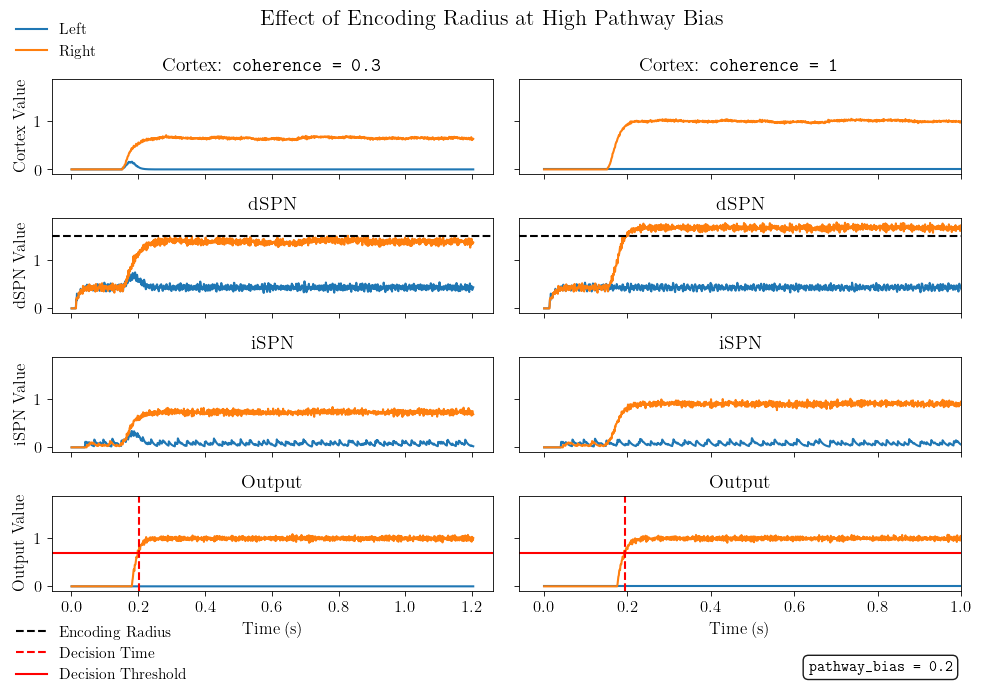

Saved: ..\..\figures\learning\suite3\Encoding Radius.pdf
Saved: ..\..\figures\learning\suite3\Encoding Radius.png


In [32]:
# ---- Parameters -----
task_seed = 1 
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )

task_params_low = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = 0.30,
    noise_std = 0.125
    )

task_params_high = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = 1,
    noise_std = 0.125
    )

# ---- Run decision-making task ----

# Low coherence
task_result_low = run_task(
    model_params = model_parameters,
    dots_params = task_params_low,
    trial_params = trial_params,
    return_probes = True,
    pathway_bias = 0.2
)
# High coherence
task_result_high = run_task(
    model_params = model_parameters,
    dots_params = task_params_high,
    trial_params = trial_params,
    return_probes = True,
    pathway_bias = 0.2
)

# ---- Get decision time for high pathway bias condition ----
decision_time_low = task_result_low.decision_info['RT (ms)']/1000 + t_warmup
decision_time_high = task_result_high.decision_info['RT (ms)']/1000 + t_warmup

# ---- Extract relevant probe data ----
probes_low= task_result_low.probes
probes_high= task_result_high.probes


# Time
time_low = probes_low['time']
time_high = probes_high['time']

# Cortex, dSPN, iSPN and output probes
cortex_probe_low = probes_low['cortex']
dSPN_probe_low = probes_low['dSPN']
iSPN_probe_low = probes_low['iSPN']
output_probe_low = probes_low['output']

cortex_probe_high = probes_high['cortex']
dSPN_probe_high = probes_high['dSPN']
iSPN_probe_high = probes_high['iSPN']
output_probe_high = probes_high['output']

# ---- Plot ----
fig, ax = plt.subplots(4, 2, figsize=figure_size('double'), sharex = 'col', sharey = True)

# Low coherence
Left, = ax[0,0].plot(time_low, cortex_probe_low[:,0], label = 'Left')
Right, = ax[0,0].plot(time_low, cortex_probe_low[:,1], label = 'Right')
ax[0,0].set_title(r'Cortex: \texttt{coherence = 0.3}')


ax[1,0].plot(time_low, dSPN_probe_low[:,0])
ax[1,0].plot(time_low, dSPN_probe_low[:,1])
ax[1,0].set_title('dSPN')

ax[2,0].plot(time_low, iSPN_probe_low[:,0])
ax[2,0].plot(time_low, iSPN_probe_low[:,1])
ax[2,0].set_title('iSPN')

ax[3,0].plot(time_low, output_probe_low[:,0])
ax[3,0].plot(time_low, output_probe_low[:,1])
ax[3,0].axhline(decision_threshold, color='r', linestyle='-')
ax[3,0].set_title('Output')

# High coherence
ax[0,1].plot(time_high, cortex_probe_high[:,0])
ax[0,1].plot(time_high, cortex_probe_high[:,1])
ax[0,1].set_title(r'Cortex: \texttt{coherence = 1}')

ax[1,1].plot(time_high, dSPN_probe_high[:,0])
ax[1,1].plot(time_high, dSPN_probe_high[:,1])
ax[1,1].set_title('dSPN')

ax[2,1].plot(time_high, iSPN_probe_high[:,0])
ax[2,1].plot(time_high, iSPN_probe_high[:,1])
ax[2,1].set_title('iSPN')

ax[3,1].plot(time_high, output_probe_high[:,0])
ax[3,1].plot(time_high, output_probe_high[:,1])
ax[3,1].set_title('Output')
ax[3,1].set_xlim(right = 1)

# - Set axes labels -
# x-axis
ax[3,0].set_xlabel('Time (s)')
ax[3,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Cortex Value')
ax[1,0].set_ylabel('dSPN Value')
ax[2,0].set_ylabel('iSPN Value')
ax[3,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
ax[3,0].axvline(decision_time_low, color='r', linestyle='--', label='Decision Time')
ax[3,1].axvline(decision_time_high, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[3,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')
line_15 = ax[1,0].axhline(1.5, color='k', linestyle='--', label='Encoding Radius')
ax[1,1].axhline(1.5, color='k', linestyle='--')



#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[line_15, decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{pathway_bias = 0.2}}"

)

fig.text(
    0.96, 0.05,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Effect of Encoding Radius at High Pathway Bias')
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

save_plot(fig, 'Encoding Radius', folder='../../figures/learning/suite3', formats=('pdf', 'png'))

The represented dSPN value exceeds the encoding radius at high coherence. This appears to be a likely cause for the increased reaction time standard deviation at $100\%$ coherence

Finally, it could be of interest to extract the numerical values for reaction time mean and standard deviation. Box plots of the reaction time distribution is included as well.

In [33]:
rt_0125_b020_table = (
    summary_stats_20
    .loc[summary_stats_20["noise_std"].eq(0.125)]
    .assign(
        Coherence=lambda d: d["coherence"] * 100,
        **{
            "RT Mean": lambda d: d["Mean Correct RT (ms)"],
            "RT Mean CI Low": lambda d: d["Mean Correct RT (ms)"] - d["Mean Correct RT CI Margin (ms)"],
            "RT Mean CI High": lambda d: d["Mean Correct RT (ms)"] + d["Mean Correct RT CI Margin (ms)"],
            "RT std": lambda d: d["Correct RT std (ms)"],
            "RT std CI Low": lambda d: d["Correct RT std CI Low (ms)"],
            "RT std CI High": lambda d: d["Correct RT std CI High (ms)"],
        },
    )
    [["Coherence", "RT Mean", "RT Mean CI Low", "RT Mean CI High", "RT std", "RT std CI Low", "RT std CI High"]]
    .sort_values("Coherence")
    .reset_index(drop=True)
    .round(2)
)

rt_0125_b020_table


,Coherence,RT Mean,RT Mean CI Low,RT Mean CI High,RT std,RT std CI Low,RT std CI High
0,1.0,84.18,78.51,89.85,23.23,18.09,31.43
1,3.0,75.52,71.98,79.06,17.39,12.11,25.19
2,5.0,67.28,66.01,68.55,6.35,4.79,8.76
3,8.0,62.39,61.67,63.11,3.61,2.63,6.05
4,10.0,60.90,60.48,61.32,2.13,1.90,2.47
5,15.0,56.75,56.43,57.07,1.63,1.44,1.90
6,30.0,52.27,52.06,52.48,1.03,0.91,1.18
7,100.0,44.00,43.60,44.40,2.02,1.92,2.15


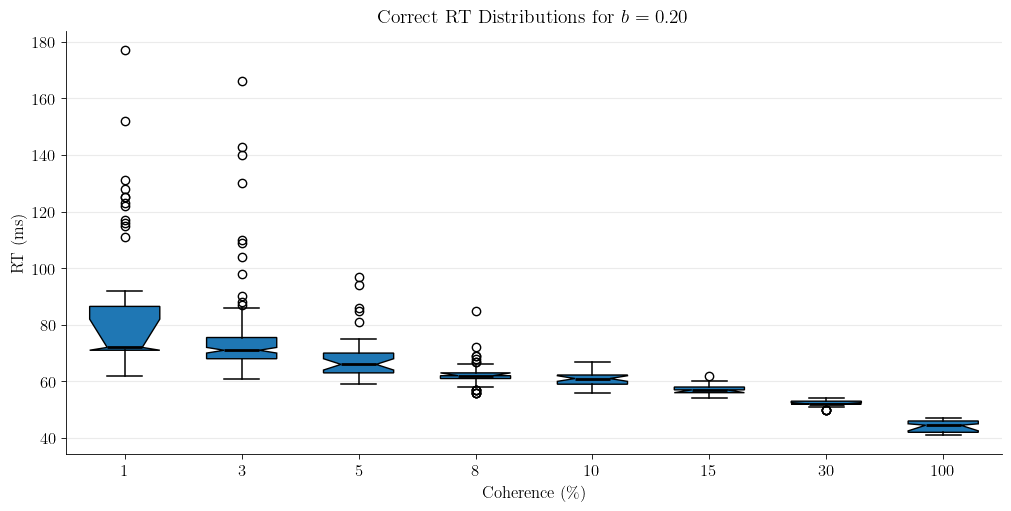

Saved: ..\..\figures\rt\Correct RT Distribution.pdf
Saved: ..\..\figures\rt\Correct RT Distribution.png


In [34]:
noise = 0.125

rt_col = "decision_info.RT (ms)"
noise_col = "stim_info.noise_std"
group_col = "stim_info.coherence"

# - Arrange data for boxplot -
plot_df = trial_data_20[
    np.isclose(trial_data_20[noise_col], noise)
    & trial_data_20[rt_col].notna()
    & (trial_data_20["decision_info.Outcome"] == "Correct Decision")
].copy()

levels = sorted(plot_df[group_col].unique())
box_data = [
    plot_df.loc[plot_df[group_col] == level, rt_col].to_numpy()
    for level in levels
]

positions = np.arange(len(levels))

# - Plot -
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

ax.boxplot(
    box_data,
    positions=positions,
    notch=True,
    widths=0.6,
    bootstrap=10000,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black", linewidth=1.1),
    capprops=dict(color="black", linewidth=1.1),
)

ax.set_xticks(positions)
ax.set_xticklabels([int(level * 100) for level in levels])
ax.set_xlabel("Coherence $(\%)$")
ax.set_ylabel("RT (ms)")
ax.set_title(r"Correct RT Distributions for $b = 0.20$")

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.show()

save_plot(fig, 'Correct RT Distribution', folder='../../figures/rt', formats=('pdf', 'png'))